New Kullback-Leibler Divergence regularization breaks training, resulting Profiles are all nan. Use this notebook
to find out why and how to fix it. Also can be used for later problems when adapting the loss.

In [165]:
import importlib
import json
import logging
import numpy as np
from pathlib import Path

from modules import model as mdl
from modules import training, SequenceRepresentation, ProfileFindingSetup, ModelDataSet, plotting

In [166]:
logging.basicConfig(format="%(asctime)s %(levelname)s: %(message)s", 
                    encoding='utf-8', level=logging.DEBUG)

Running on dummy data

In [331]:
genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence("species1", "chr0", "+", 0, sequence="AAAAACCCCCAAAAA")]),
           SequenceRepresentation.Genome([SequenceRepresentation.Sequence("species2", "chr0", "+", 0, sequence="AAAAACCCCCAAAAA")])]
settings = {'rand_seed': 42,
            'tile_size': 100,
            'tiles_per_X': 1,
            'batch_size': 1,
            'prefetch': 3,
            'n_best_profiles': 2,
            'U': 200,
            'enforceU': False,
            'minU': 10,
            'minOcc': 8,
            'overlapTilesize': 6,
            'k': 12,
            'midK': 8,
            's': 0,
            'gamma': 1.0,
            'l2': 0.0,
            'kld': 0.1,
            'match_score_factor': 0.7,
            'learning_rate': 2.0,
            'lr_patience': 5,
            'lr_factor': 0.75,
            'rho': 0.0,
            'sigma': 1.0,
            'phylo_t': 0.0,
            'profile_plateau': 10,
            'profile_plateau_dev': 150}

In [341]:
data = ModelDataSet.ModelDataSet(data=genomes,
                                 datamode=ModelDataSet.DataMode.DNA,
                                 tile_size=15,
                                 tiles_per_X=1,
                                 batch_size=1,
                                 prefetch=1)

setup = ProfileFindingSetup.ProfileFindingTrainingSetup(data=data,
                                                        U=1,
                                                        k=5,
                                                        midK=1,
                                                        s=0,
                                                        epochs=1,
                                                        gamma=settings["gamma"],
                                                        l2=0.0,
                                                        kld=0.0,
                                                        match_score_factor=settings["match_score_factor"],
                                                        learning_rate=settings["learning_rate"],
                                                        lr_patience=settings["lr_patience"],
                                                        lr_factor=settings["lr_factor"],
                                                        rho=settings["rho"],
                                                        sigma=settings["sigma"],
                                                        profile_plateau=settings["profile_plateau"],
                                                        profile_plateau_dev=settings["profile_plateau_dev"],
                                                        n_best_profiles=1,
                                                        phylo_t=settings["phylo_t"])

# (k, alphabet_size, U)
setup.initProfiles = np.expand_dims(np.array([[0,1e10,0,0],[0,1e10,0,0],[0,1e10,0,0],[0,1e10,0,0],[0,1e10,0,0]], dtype=np.float32), -1) # matches "C" perfectly

In [342]:
importlib.reload(mdl)
model = mdl.SpecificProfile(setup, settings["rand_seed"])

2025-03-27 20:37:40,583 DEBUG: [model.__init__] >>> setting tf global seed to 42
2025-03-27 20:37:40,586 DEBUG: [model.__init__] >>> Using initProfiles from training setup instead of random


In [343]:
ds = data.getDataset(repeat=True, withPosTracking=False, original_data=False)

In [344]:
for x in ds.take(1):
    X, _ = x

print(X.shape)

(1, 1, 2, 2, 15, 4)


2025-03-27 20:37:41.357963: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [345]:
model.getP()

<tf.Tensor: shape=(5, 4, 1), dtype=float32, numpy=
array([[[0.],
        [1.],
        [0.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        [0.]]], dtype=float32)>

In [346]:
S, R, Z = model.call(X[0], model.getP())

In [347]:
Z.shape

TensorShape([1, 2, 2, 11, 1])

In [348]:
Z[0, 0, 0, :, 0]

<tf.Tensor: shape=(11,), dtype=float32, numpy=
array([-69.07755 , -53.470284, -37.863014, -22.255743,  -6.648473,
         8.958797,  -6.648473, -22.255743, -37.863014, -53.470284,
       -69.07755 ], dtype=float32)>

In [349]:
score, loss_by_unit = model.lossfun(Z, model.P_logit)

2025-03-27 20:37:44,153 DEBUG: [model.lossfun] >>> 
Z: [[[-69.07755  -53.470284 -37.863014 -22.255743  -6.648473   8.958797
    -6.648473 -22.255743 -37.863014 -53.470284 -69.07755  -69.07755
   -69.07755  -69.07755  -69.07755  -69.07755  -69.07755  -69.07755
   -69.07755  -69.07755  -69.07755  -69.07755 ]]

 [[-69.07755  -53.470284 -37.863014 -22.255743  -6.648473   8.958797
    -6.648473 -22.255743 -37.863014 -53.470284 -69.07755  -69.07755
   -69.07755  -69.07755  -69.07755  -69.07755  -69.07755  -69.07755
   -69.07755  -69.07755  -69.07755  -69.07755 ]]],
Zsm: [[[1.2860125e-34 7.7160400e-28 4.6296208e-21 2.7777756e-14 1.6666658e-07
   9.9999964e-01 1.6666658e-07 2.7777756e-14 4.6296208e-21 7.7160400e-28
   1.2860125e-34 1.2860125e-34 1.2860125e-34 1.2860125e-34 1.2860125e-34
   1.2860125e-34 1.2860125e-34 1.2860125e-34 1.2860125e-34 1.2860125e-34
   1.2860125e-34 1.2860125e-34]]

 [[1.2860125e-34 7.7160400e-28 4.6296208e-21 2.7777756e-14 1.6666658e-07
   9.9999964e-01 1.6666658e-07

---

Running on real data

In [154]:
genomes = SequenceRepresentation.loadJSONGenomeList("/home/matthis/PhD/mnt/brain/genomegraph/runs/20250306_new_experiments/test_20250325/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak/training_sequences_0.json")
with open("/home/matthis/PhD/mnt/brain/genomegraph/runs/20250306_new_experiments/test_20250325/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak/settings.json", "rt") as f:
    settings = json.load(f)

In [155]:
len(genomes)

36394

In [163]:
# settings

In [157]:
data = ModelDataSet.ModelDataSet(data=genomes[:1000],
                                 datamode=ModelDataSet.DataMode.DNA,
                                 tile_size=settings["tile_size"],
                                 tiles_per_X=settings["tiles_per_X"],
                                 batch_size=settings["batch_size"],
                                 prefetch=settings["prefetch"])

In [158]:
setup = ProfileFindingSetup.ProfileFindingTrainingSetup(data=data,
                                                        U=settings["U"],
                                                        k=settings["k"],
                                                        midK=settings["midK"],
                                                        s=settings["s"],
                                                        epochs=350,
                                                        gamma=settings["gamma"],
                                                        l2=0.0,
                                                        kld=0.01,
                                                        match_score_factor=settings["match_score_factor"],
                                                        learning_rate=settings["learning_rate"],
                                                        lr_patience=settings["lr_patience"],
                                                        lr_factor=settings["lr_factor"],
                                                        rho=settings["rho"],
                                                        sigma=settings["sigma"],
                                                        profile_plateau=settings["profile_plateau"],
                                                        profile_plateau_dev=settings["profile_plateau_dev"],
                                                        n_best_profiles=1,
                                                        phylo_t=settings["phylo_t"])

In [159]:
importlib.reload(mdl)
model = mdl.SpecificProfile(setup, settings["rand_seed"])

2025-03-27 16:56:59,852 DEBUG: [model.__init__] >>> setting tf global seed to 42


In [160]:
model.debug_nan_count = 0
model.train()

2025-03-27 16:56:59,871 DEBUG: [model.train.setLR] >>> Setting learning rate to 2.0
2025-03-27 16:57:01,070 DEBUG: [model.getR] >>> nan in P: Tensor("cond/Any:0", shape=(200,), dtype=bool) Tensor("cond/boolean_mask/GatherV2:0", shape=(12, 4, None), dtype=float32)
2025-03-27 16:57:01,091 DEBUG: [model.getR] >>> Q: Tensor("Maximum:0", shape=(4,), dtype=float32)
2025-03-27 16:57:01,127 DEBUG: [model.getZ] >>> nan in R
2025-03-27 16:57:01,156 DEBUG: [model.getZ] >>> nan in X
2025-03-27 16:57:01,187 DEBUG: [model.getZ] >>> nan in Z
2025-03-27 16:57:01,405 DEBUG: [model.getR] >>> nan in P: Tensor("cond/Any:0", shape=(200,), dtype=bool) Tensor("cond/boolean_mask/GatherV2:0", shape=(12, 4, None), dtype=float32)
2025-03-27 16:57:01,424 DEBUG: [model.getR] >>> Q: Tensor("Maximum:0", shape=(4,), dtype=float32)
2025-03-27 16:57:01,457 DEBUG: [model.getZ] >>> nan in R
2025-03-27 16:57:01,483 DEBUG: [model.getZ] >>> nan in X
2025-03-27 16:57:01,510 DEBUG: [model.getZ] >>> nan in Z
2025-03-27 16:57:0

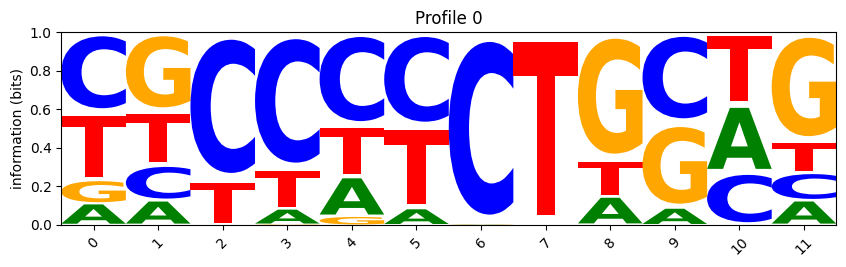

In [161]:
plotting.plotLogo(model.profile_report.P, data.alphabet)